In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jaydeepvaishya/weather-dataset/Combined12.csv


## DATASET OVERVIEW

In [2]:
df=pd.read_csv('/kaggle/input/datasets/jaydeepvaishya/weather-dataset/Combined12.csv')
df

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
0,971.5,0.25,9.0,7.0,10.7,0.00,0,0
1,972.3,0.97,10.5,6.7,13.5,0.00,0,0
2,972.4,0.74,6.5,3.9,9.1,0.00,0,0
3,973.2,0.15,5.1,3.7,7.7,0.00,0,0
4,975.7,0.12,5.2,2.6,8.3,0.00,0,0
...,...,...,...,...,...,...,...,...
533307,1015.0,2.11,19.7,15.0,27.3,3.14,325,0
533308,1015.0,2.11,19.7,15.0,27.3,24.07,147,2
533309,1015.0,2.11,19.7,15.0,27.3,3.30,247,0
533310,1015.0,2.11,19.7,15.0,27.3,25.41,308,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 533312 entries, 0 to 533311
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Pressure          533312 non-null  float64
 1   global_radiation  533312 non-null  float64
 2   temp_mean(c)      533312 non-null  float64
 3   temp_min(c)       533312 non-null  float64
 4   temp_max(c)       533312 non-null  float64
 5   Wind_Speed        533312 non-null  float64
 6   Wind_Bearing      533312 non-null  int64  
 7   normalized_label  533312 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 32.6 MB


In [4]:
df.describe()

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
count,533312.000000,533312.000000,533312.000000,533312.000000,533312.000000,533312.000000,533312.000000,533312.000000
mean,1011.436192,1.310346,12.646057,8.648474,16.871960,11.885974,192.501742,0.906152
std,3.241187,0.897191,6.519240,5.867740,7.692881,7.677086,101.984936,0.992549
min,971.500000,0.030000,-11.100000,-16.000000,-8.500000,0.000000,0.000000,0.000000
25%,1009.800000,0.510000,7.800000,4.500000,11.100000,6.410000,130.000000,0.000000
50%,1012.300000,1.160000,13.200000,9.400000,17.200000,11.040000,190.000000,1.000000
75%,1013.900000,2.010000,17.500000,13.300000,22.400000,15.620000,288.000000,2.000000
max,1015.000000,3.600000,28.600000,22.000000,37.000000,47.530000,359.000000,3.000000


In [5]:
df.shape

(533312, 8)

## DATA CLEANING

In [6]:
df.duplicated().sum()

np.int64(16264)

In [7]:
df[df.duplicated()]

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
9325,1002.3,1.11,12.2,8.3,16.2,25.76,260,3
9342,1002.3,0.59,11.6,10.0,16.5,25.76,260,3
9359,1002.3,2.02,11.9,6.4,17.1,25.76,260,3
9376,1002.3,1.77,17.4,13.0,22.1,25.76,260,3
9393,1002.3,0.35,5.9,3.3,8.3,25.76,260,3
...,...,...,...,...,...,...,...,...
533258,1015.0,2.11,19.7,15.0,27.3,0.00,0,0
533260,1015.0,2.11,19.7,15.0,27.3,11.27,250,0
533261,1015.0,2.11,19.7,15.0,27.3,12.88,160,0
533287,1015.0,2.11,19.7,15.0,27.3,17.71,0,2


In [8]:
duplicates = df[df.duplicated(keep=False)]
duplicates

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
9324,1002.3,1.11,12.2,8.3,16.2,25.76,260,3
9325,1002.3,1.11,12.2,8.3,16.2,25.76,260,3
9341,1002.3,0.59,11.6,10.0,16.5,25.76,260,3
9342,1002.3,0.59,11.6,10.0,16.5,25.76,260,3
9358,1002.3,2.02,11.9,6.4,17.1,25.76,260,3
...,...,...,...,...,...,...,...,...
533260,1015.0,2.11,19.7,15.0,27.3,11.27,250,0
533261,1015.0,2.11,19.7,15.0,27.3,12.88,160,0
533262,1015.0,2.11,19.7,15.0,27.3,11.27,160,0
533287,1015.0,2.11,19.7,15.0,27.3,17.71,0,2


In [9]:
duplicates = df[df.duplicated(keep=False)]
duplicates = duplicates.sort_values(by=list(df.columns))
duplicates

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
9477,1002.3,0.11,1.4,0.3,3.1,25.76,260,2
9478,1002.3,0.11,1.4,0.3,3.1,25.76,260,2
9698,1002.3,0.13,3.7,3.2,5.0,25.76,260,2
9699,1002.3,0.13,3.7,3.2,5.0,25.76,260,2
9443,1002.3,0.14,10.2,7.6,12.1,25.76,260,2
...,...,...,...,...,...,...,...,...
525049,1015.0,3.30,26.5,18.5,32.5,11.27,250,1
525035,1015.0,3.30,26.5,18.5,32.5,12.88,160,1
525050,1015.0,3.30,26.5,18.5,32.5,12.88,160,1
525024,1015.0,3.30,26.5,18.5,32.5,17.71,0,3


**We do not drop the duplicate values here as they may have been recorded at different dates or even times, we have no information as to how the data has been collected.**

In [10]:
df.nunique()

Pressure             332
global_radiation     353
temp_mean(c)         340
temp_min(c)          312
temp_max(c)          393
Wind_Speed          1387
Wind_Bearing         357
normalized_label       4
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(16264)

In [12]:
df.isnull().sum()

Pressure            0
global_radiation    0
temp_mean(c)        0
temp_min(c)         0
temp_max(c)         0
Wind_Speed          0
Wind_Bearing        0
normalized_label    0
dtype: int64

## EDA

In [13]:
df['normalized_label'].value_counts()

normalized_label
0    239241
1    155709
2     87533
3     50829
Name: count, dtype: int64

**We first need to understand what each and every label means, that is, what is it actually referring to?**

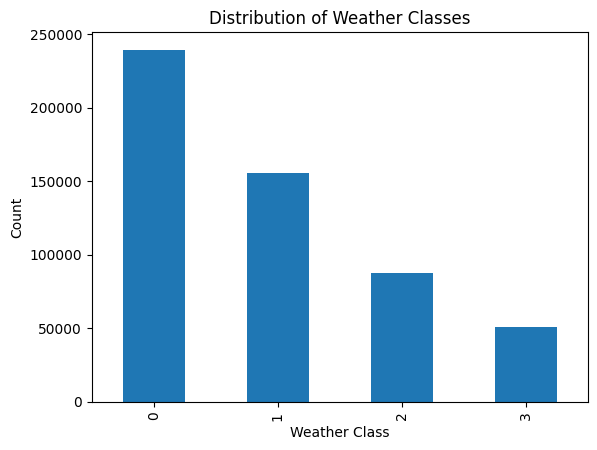

In [14]:
df['normalized_label'].value_counts().plot(kind='bar')
plt.xlabel("Weather Class")
plt.ylabel("Count")
plt.title("Distribution of Weather Classes")
plt.show()

**The graph is heavily imbalanced, with Label 0 being quite overrepresented, and Labels 1,2 and 3 being in the minority.**

In [15]:
df.groupby('normalized_label').mean(numeric_only=True)

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing
normalized_label,,,,,,,
0,1011.328134,0.925251,11.349379,8.212900,14.823907,8.298518,185.547561
1,1012.312363,1.944292,14.891863,9.491525,20.342833,8.175522,186.060896
2,1010.134236,0.902814,11.137690,8.021497,14.586228,22.346179,211.396171
3,1011.502853,1.882696,14.467029,9.195760,19.815334,22.124304,212.426135



**Now,
      Label 0: Relatively cold and calm conditions    
      Label 1: Relatively hot Weather but calm conditions    
      Label 2: Relatively cold Weather but very windy conditions    
      Label 3: Relatively hot Weather but very windy conditions**


**Hence we can say that normalized labels are weather conditions based on temperature, global radiation and wind conditions.**

Text(0, 0.5, 'Pressure')

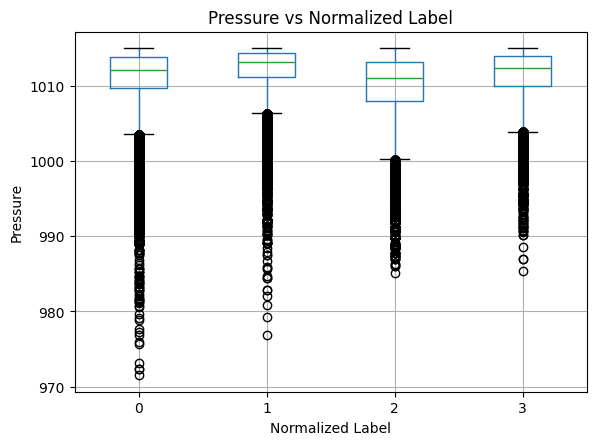

In [16]:
df.boxplot(column='Pressure', by='normalized_label')
plt.title("Pressure vs Normalized Label")
plt.suptitle("")
plt.xlabel("Normalized Label")
plt.ylabel("Pressure")

**Here, the pressure values for all the normalized labels, 50% of the values for pressure across the normalized labels lie in a similar range of 1008 to 1020 respectively, their whiskers also overlap to a decent degree, that makes this column not useful while trying to identify the separate weather classes.**

Text(0, 0.5, 'Radiation')

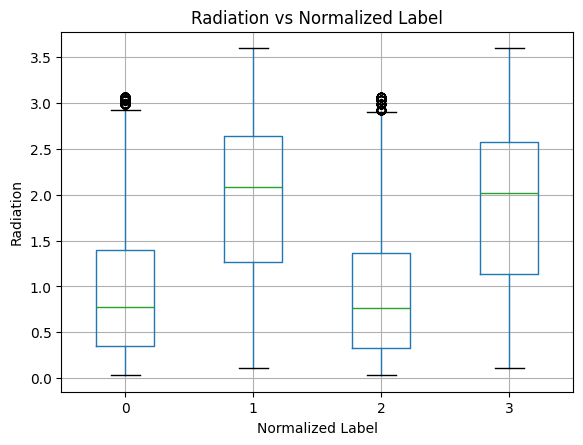

In [17]:
df.boxplot(column='global_radiation', by='normalized_label')
plt.title("Radiation vs Normalized Label")
plt.suptitle("")
plt.xlabel("Normalized Label")
plt.ylabel("Radiation")

**Labels 1 and 3 have clearly higher levels of radiation as compared to 0 and 2, this clearly separates them in two separate groups. Hence it can be useful when trying to predict the weather classes with our model.**

Text(0, 0.5, 'Mean Temperature')

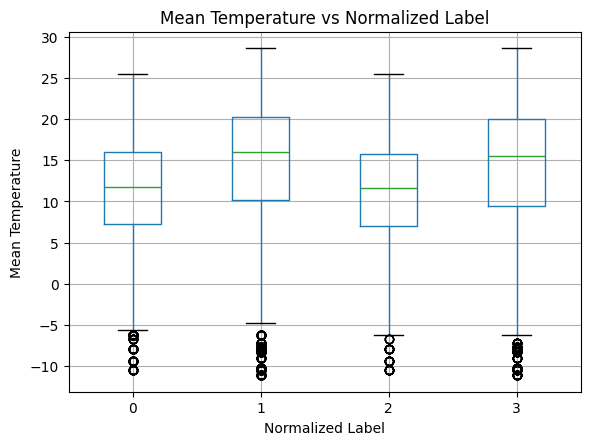

In [18]:
df.boxplot(column='temp_mean(c)', by='normalized_label')
plt.title("Mean Temperature vs Normalized Label")
plt.suptitle("")
plt.xlabel("Normalized Label")
plt.ylabel("Mean Temperature")

**Labels 1 nd 3 clearly have a higher mean temperature overall as compared to labels 0 and 2, this essentially splits them into two groups, which are, colder weather and warmer weather respectively. This can be used in our prediction model to help predict the weather classes.**

Text(0, 0.5, 'Min Temperature')

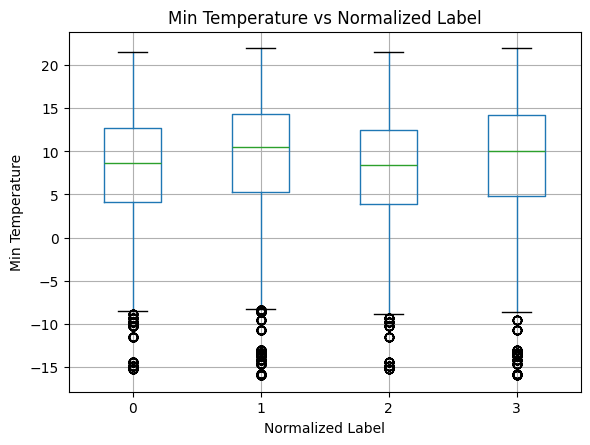

In [19]:
df.boxplot(column='temp_min(c)', by='normalized_label')
plt.title("Min Temperature vs Normalized Label")
plt.suptitle("")
plt.xlabel("Normalized Label")
plt.ylabel("Min Temperature")

**The distinction between classes isn't as clear for weather classes using minimum temperature, their medians are almost overlapping completely, same goes for where 50% of their distribution lies, their whiskers align a bit as well, hence min temp by itself is not a good measure to predict weather classes. Assuming that the lowest temperatures usually occur during night-time.**

Text(0, 0.5, 'Max Temperature')

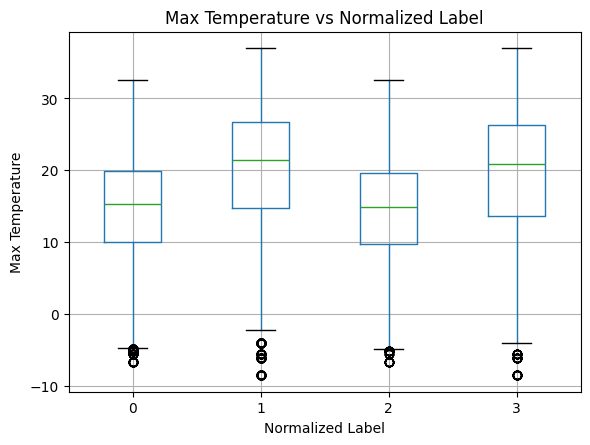

In [20]:
df.boxplot(column='temp_max(c)', by='normalized_label')
plt.title("Max Temperature vs Normalized Label")
plt.suptitle("")
plt.xlabel("Normalized Label")
plt.ylabel("Max Temperature")

**Max temperature follows in the footsteps of mean temperature, that is, Labels 1 and 3 have a higher peaks and and Labels 0 and 2 have much lower peaks, this classifies them again into two groups, which are respectively, High Peaks and Low Peaks, assuming that this max temperature is occurs during day time.**

Text(0, 0.5, 'Wind Speed')

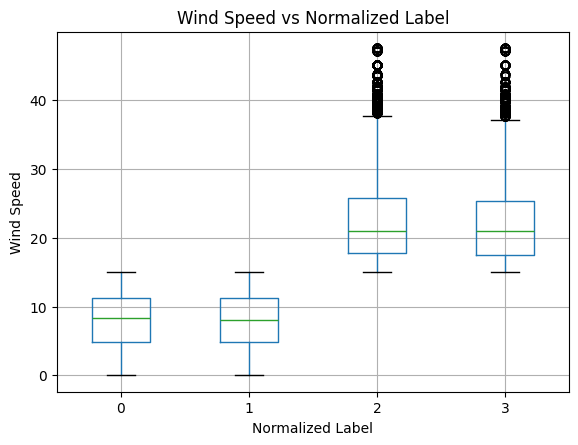

In [21]:
df.boxplot(column='Wind_Speed', by='normalized_label')
plt.title("Wind Speed vs Normalized Label")
plt.suptitle("")
plt.xlabel("Normalized Label")
plt.ylabel("Wind Speed")

**Labels 2 and 3 have high wind speeds and labels 0 and 1 have comparatively lower wind speeds,it shows that the existing labels exhibit two wind-speed groupings, very windy and moderately windy. This can be a good feature to consider when building our prediction model for weather classes.**

Text(0, 0.5, 'Wind Bearing')

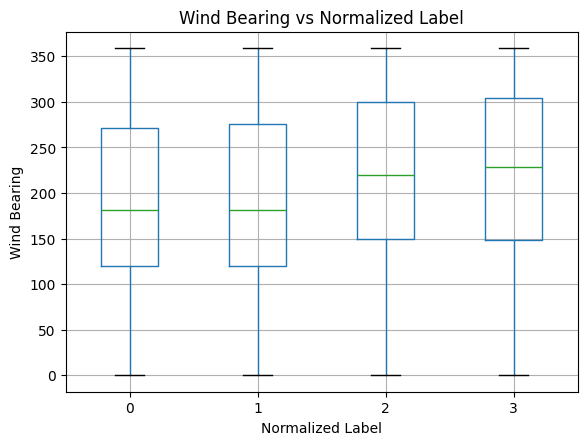

In [22]:
df.boxplot(column='Wind_Bearing', by='normalized_label')
plt.title("Wind Bearing vs Normalized Label")
plt.suptitle("")
plt.xlabel("Normalized Label")
plt.ylabel("Wind Bearing")

**The box plots for wind bearing almost overlap with each other, the median wind bearing hangs between, 180 and 230, moreover their whiskers overlap as well, hence wind bearing alone cannot be a good feature for our prediction model, though we still keep it as it could be used with something else.**

In [23]:
df['temp_range']=df['temp_max(c)']-df['temp_min(c)']

**Temperature range captures the daily variation in temperature, which may provide additional information beyond the individual minimum and maximum temperatures.**

Text(0, 0.5, 'Temperature Range')

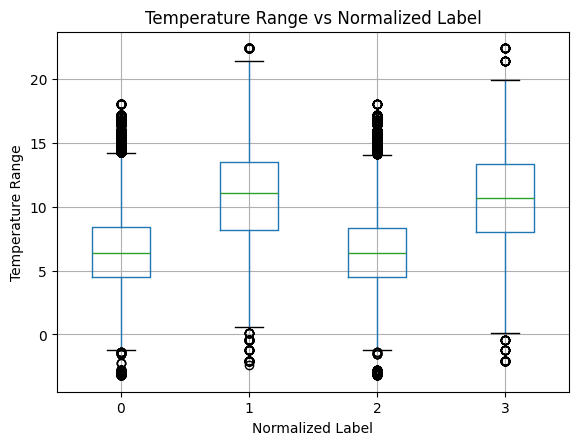

In [24]:
df.boxplot(column='temp_range', by='normalized_label')
plt.title("Temperature Range vs Normalized Label")
plt.suptitle("")
plt.xlabel("Normalized Label")
plt.ylabel("Temperature Range")

**Labels 1 and 3 show higher temperature ranges than Labels 0 and 2, suggesting two broad groupings among the weather classes: Higher Temperature Range (Labels 1 and 3) and Lower Temperature Range (Labels 0 and 2). This suggests that temperature range may be a useful feature to consider when building our prediction model for weather classes.**

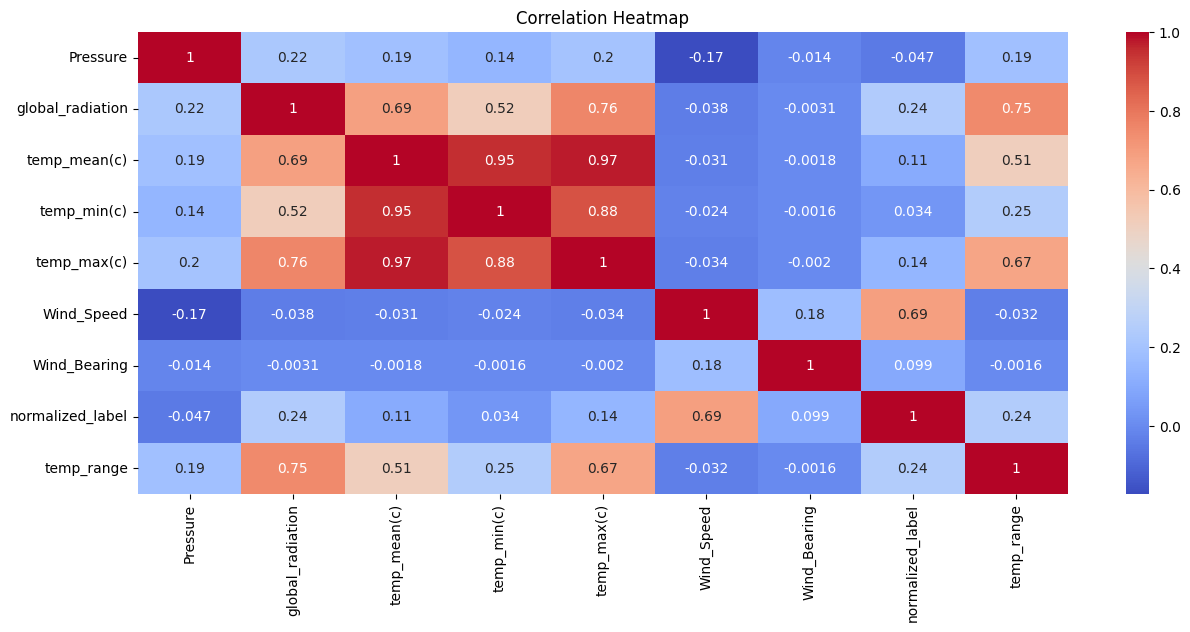

In [25]:
plt.figure(figsize=(15, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**There is a very strong positive correlation between wind speed and normalized label, hence we can choose wind speed, global radiation and temp range also have a positive correlation with normalized label, albeit a bit weak, they can also be considered for our prediction model. There is also extreme multi collinearity (0.97) between the temperature variables, so we might have to think about dropping temp mean. Wind Bearing and Pressure have almost 0 correlation with the target variable, so we might have to think on dropping those as well.**

In [26]:
df

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label,temp_range
0,971.5,0.25,9.0,7.0,10.7,0.00,0,0,3.7
1,972.3,0.97,10.5,6.7,13.5,0.00,0,0,6.8
2,972.4,0.74,6.5,3.9,9.1,0.00,0,0,5.2
3,973.2,0.15,5.1,3.7,7.7,0.00,0,0,4.0
4,975.7,0.12,5.2,2.6,8.3,0.00,0,0,5.7
...,...,...,...,...,...,...,...,...,...
533307,1015.0,2.11,19.7,15.0,27.3,3.14,325,0,12.3
533308,1015.0,2.11,19.7,15.0,27.3,24.07,147,2,12.3
533309,1015.0,2.11,19.7,15.0,27.3,3.30,247,0,12.3
533310,1015.0,2.11,19.7,15.0,27.3,25.41,308,2,12.3


In [27]:
df

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label,temp_range
0,971.5,0.25,9.0,7.0,10.7,0.00,0,0,3.7
1,972.3,0.97,10.5,6.7,13.5,0.00,0,0,6.8
2,972.4,0.74,6.5,3.9,9.1,0.00,0,0,5.2
3,973.2,0.15,5.1,3.7,7.7,0.00,0,0,4.0
4,975.7,0.12,5.2,2.6,8.3,0.00,0,0,5.7
...,...,...,...,...,...,...,...,...,...
533307,1015.0,2.11,19.7,15.0,27.3,3.14,325,0,12.3
533308,1015.0,2.11,19.7,15.0,27.3,24.07,147,2,12.3
533309,1015.0,2.11,19.7,15.0,27.3,3.30,247,0,12.3
533310,1015.0,2.11,19.7,15.0,27.3,25.41,308,2,12.3


In [28]:
columns = ['global_radiation','temp_min(c)','temp_max(c)','Wind_Speed','normalized_label','temp_range']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if lower<0:
        lower=0
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print(f"Normal range: {lower:.2f} to {upper:.2f}")
    print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)\n")

global_radiation
Normal range: 0.00 to 4.26
Outliers: 0 (0.00%)

temp_min(c)
Normal range: 0.00 to 26.50
Outliers: 45999 (8.63%)

temp_max(c)
Normal range: 0.00 to 39.35
Outliers: 5061 (0.95%)

Wind_Speed
Normal range: 0.00 to 29.43
Outliers: 14750 (2.77%)

normalized_label
Normal range: 0.00 to 5.00
Outliers: 0 (0.00%)

temp_range
Normal range: 0.00 to 18.65
Outliers: 1821 (0.34%)



**We do not drop any of the values outside of the IQR, since this is a weather dataset, these values could very well be legitimate values.**

In [29]:
df.normalized_label.value_counts()

normalized_label
0    239241
1    155709
2     87533
3     50829
Name: count, dtype: int64

## LINEAR REGRESSION

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[['global_radiation', 'temp_min(c)', 'temp_max(c)', 'Wind_Speed','Wind_Bearing','Pressure','temp_mean(c)']]
y = df['normalized_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

adjusted_r2 = 1 - (1 - r2) * ((X_test.shape[0] - 1) /(X_test.shape[0] - X_test.shape[1] - 1))

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Intercept: {model.intercept_:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"Adjusted R2 Score: {adjusted_r2:.4f}")
print(f"Training Score (R2): {train_score:.4f}")
print(f"Testing Score (R2): {test_score:.4f}")

Intercept: -5.6495
MAE: 0.5291
MSE: 0.4253
RMSE: 0.6522
R2 Score: 0.5688
Adjusted R2 Score: 0.5688
Training Score (R2): 0.5690
Testing Score (R2): 0.5688


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[['global_radiation', 'temp_min(c)', 'temp_max(c)', 'temp_range','Wind_Speed']]
y = df['normalized_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

adjusted_r2 = 1 - (1 - r2) * ((X_test.shape[0] - 1) /(X_test.shape[0] - X_test.shape[1] - 1))

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Intercept: {model.intercept_:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"Adjusted R2 Score: {adjusted_r2:.4f}")
print(f"Training Score (R2): {train_score:.4f}")
print(f"Testing Score (R2): {test_score:.4f}")

Intercept: -0.6258
MAE: 0.5299
MSE: 0.4263
RMSE: 0.6529
R2 Score: 0.5679
Adjusted R2 Score: 0.5678
Training Score (R2): 0.5680
Testing Score (R2): 0.5679


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

X = df[['global_radiation','temp_min(c)','temp_max(c)','temp_range','Wind_Speed']]

y = df['normalized_label']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

print("Classification Report:")
print(classification_report(y_test, y_pred))

Training Accuracy: 0.7910
Testing Accuracy: 0.7903

Confusion Matrix:
[[41415  6389     0     0]
 [10067 21081     0     0]
 [   30     6 15341  2129]
 [    6    12  3728  6459]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83     47804
           1       0.77      0.68      0.72     31148
           2       0.80      0.88      0.84     17506
           3       0.75      0.63      0.69     10205

    accuracy                           0.79    106663
   macro avg       0.78      0.76      0.77    106663
weighted avg       0.79      0.79      0.79    106663

